# Tarea 3 - Ciencia de Redes
Antonia Luengo

## Preparación del entorno

In [ ]:
!pip install graph_tiger networkx pandas numpy matplotlib seaborn scipy

  Preparing metadata (setup.py) ... done
  Created wheel for graph_tiger: filename=graph_tiger-0.2.5-py3-none-any.whl size=38729 sha256=dda62c80e8a4018d03983568d566de25e14b0d51fd09a82a17dd250494957020
  Stored in directory: /root/.cache/pip/wheels/9d/82/7b/057b6126fd11f59dd00a811e678f394b0e3943e4e34ae38958
Successfully built graph_tiger


### Montaje Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Importar librerias

In [ ]:
import os
import zipfile
import glob
import pandas as pd
import networkx as nx
import numpy as np
import random
import seaborn as sns
import matplotlib.pyplot as plt
from math import pi

### Descompresión

In [ ]:
# Rutas
drive_path = '/content/drive/MyDrive/dataset_metros'
local_extract_path = '/content/metros_data'

os.makedirs(local_extract_path, exist_ok=True)

# Buscar y extraer zips en la ruta principal de Drive
zip_files = glob.glob(os.path.join(drive_path, '*.zip'))
print(f"Encontrados {len(zip_files)} archivos .zip en Drive. Iniciando extracción...")

for zf in zip_files:
    try:
        with zipfile.ZipFile(zf, 'r') as zip_ref:
            zip_ref.extractall(local_extract_path)
            print(f"Extraído: {os.path.basename(zf)}")
    except Exception as e:
        print(f"Error extrayendo {zf}: {e}")

# Se verifica que sea un zip con zips dentro
nested_zips = glob.glob(os.path.join(local_extract_path, '*.zip'))
for nzf in nested_zips:
    with zipfile.ZipFile(nzf, 'r') as zip_ref:
        # Extraemos en una subcarpeta con el nombre de la ciudad
        folder_name = os.path.splitext(os.path.basename(nzf))[0]
        zip_ref.extractall(os.path.join(local_extract_path, folder_name))
    os.remove(nzf) # Borramos el zip para ahorrar espacio en Colab

print("\nExtracción en memoria local completada")

Encontrados 1 archivos .zip en Drive. Iniciando extracción...
Extraído: 1186215.zip

Extracción en memoria local completada


## Procesamiento Topológico de la Red

### Lectura datos redes ferroviarias

In [ ]:
# Buscamos todos los archivos 'network_rail.csv' en las carpetas
rail_files = glob.glob(os.path.join(local_extract_path, '**', 'network_rail.csv'), recursive=True)
cities_data = {}

print("Cargando datos ferroviarios...")
for rail_path in rail_files:
    city_dir = os.path.dirname(rail_path)
    city_name = os.path.basename(city_dir)

    try:
        # Intentamos leer forzando a Pandas a auto-detectar el separador (coma, punto y coma, tabulador, etc.)
        df_rail = pd.read_csv(rail_path, sep=None, engine='python', on_bad_lines='skip')

        # Verificamos que tenga datos
        if len(df_rail) > 0:
            cities_data[city_name] = {'rail': df_rail}
            print(f"✓ {city_name.capitalize()}: {len(df_rail)} enlaces (tramos) cargados.")
        else:
            print(f"x Omitiendo {city_name}: No contiene red ferroviaria.")

    except pd.errors.EmptyDataError:
        print(f"x Omitiendo {city_name}: El archivo está vacío.")
    except Exception as e:
        print(f"Error inesperado leyendo {city_name}: {e}")

print(f"\nTotal de ciudades listas para procesar: {len(cities_data)}")

Cargando datos ferroviarios...
✓ Sydney: 975 enlaces (tramos) cargados.
✓ Rome: 199 enlaces (tramos) cargados.
✓ Lisbon: 136 enlaces (tramos) cargados.
✓ Adelaide: 230 enlaces (tramos) cargados.
✓ Paris: 1094 enlaces (tramos) cargados.
✓ Melbourne: 569 enlaces (tramos) cargados.
✓ Berlin: 507 enlaces (tramos) cargados.
✓ Brisbane: 382 enlaces (tramos) cargados.
✓ Helsinki: 119 enlaces (tramos) cargados.
✓ Dublin: 185 enlaces (tramos) cargados.
✓ Luxembourg: 107 enlaces (tramos) cargados.
✓ Canberra: 4 enlaces (tramos) cargados.

Total de ciudades listas para procesar: 12


### Reducción Estricta

In [ ]:
def reduce_to_transfers_and_terminals(df_edges):
    """
    Este algoritmo replica la regla del paper:
    Solo se consideran estaciones terminales (grado 1) y de transferencia (grado > 2).
    Las estaciones de paso (grado 2) se eliminan conectando directamente sus estaciones vecinas.
    """
    src_col = 'from_stop_I' if 'from_stop_I' in df_edges.columns else df_edges.columns[0]
    tgt_col = 'to_stop_I' if 'to_stop_I' in df_edges.columns else df_edges.columns[1]

    # 1. Crear grafo original no dirigido
    G = nx.from_pandas_edgelist(df_edges, source=src_col, target=tgt_col)
    G.remove_edges_from(nx.selfloop_edges(G)) # Limpiar loops por seguridad

    # 2. Iterar hasta que no queden nodos de grado 2
    while True:
        # Encontrar todos los nodos que tienen exactamente 2 vecinos (estaciones de paso)
        degree_2_nodes = [node for node, degree in dict(G.degree()).items() if degree == 2]

        if not degree_2_nodes:
            break # Si la lista está vacía, terminamos de reducir

        # Extraer un nodo y buscar sus dos vecinos
        node_to_remove = degree_2_nodes[0]
        neighbors = list(G.neighbors(node_to_remove))

        if len(neighbors) == 2:
            u, v = neighbors
            # Crear un enlace directo entre los vecinos
            G.add_edge(u, v)

        # Eliminar la estación de paso
        G.remove_node(node_to_remove)

    return G

# Diccionario para guardar nuestros grafos finales
city_graphs = {}

for city, data in cities_data.items():
    G_reduced = reduce_to_transfers_and_terminals(data['rail'])

    # Validamos que el grafo no haya quedado vacío
    if G_reduced.number_of_nodes() > 0:
        city_graphs[city] = G_reduced
        print(f"[{city.capitalize()}] Nodos originales procesados -> {G_reduced.number_of_nodes()} terminales/transferencias. (Enlaces: {G_reduced.number_of_edges()})")
    else:
        print(f"[{city.capitalize()}] Descartada: Red no válida tras reducción.")

print(f"\n{len(city_graphs)} grafos listos para TIGER.")

[Sydney] Nodos originales procesados -> 295 terminales/transferencias. (Enlaces: 674)
[Rome] Nodos originales procesados -> 31 terminales/transferencias. (Enlaces: 42)
[Lisbon] Nodos originales procesados -> 16 terminales/transferencias. (Enlaces: 15)
[Adelaide] Nodos originales procesados -> 40 terminales/transferencias. (Enlaces: 58)
[Paris] Nodos originales procesados -> 155 terminales/transferencias. (Enlaces: 246)
[Melbourne] Nodos originales procesados -> 47 terminales/transferencias. (Enlaces: 72)
[Berlin] Nodos originales procesados -> 69 terminales/transferencias. (Enlaces: 107)
[Brisbane] Nodos originales procesados -> 82 terminales/transferencias. (Enlaces: 140)
[Helsinki] Nodos originales procesados -> 26 terminales/transferencias. (Enlaces: 39)
[Dublin] Nodos originales procesados -> 39 terminales/transferencias. (Enlaces: 79)
[Luxembourg] Nodos originales procesados -> 18 terminales/transferencias. (Enlaces: 24)
[Canberra] Nodos originales procesados -> 2 terminales/trans

Tenemos 12 grafos de 25 ya que algunas ciudades pueden no tener tren o metro, y solo otros medios de transporte.

### Visualización grafos

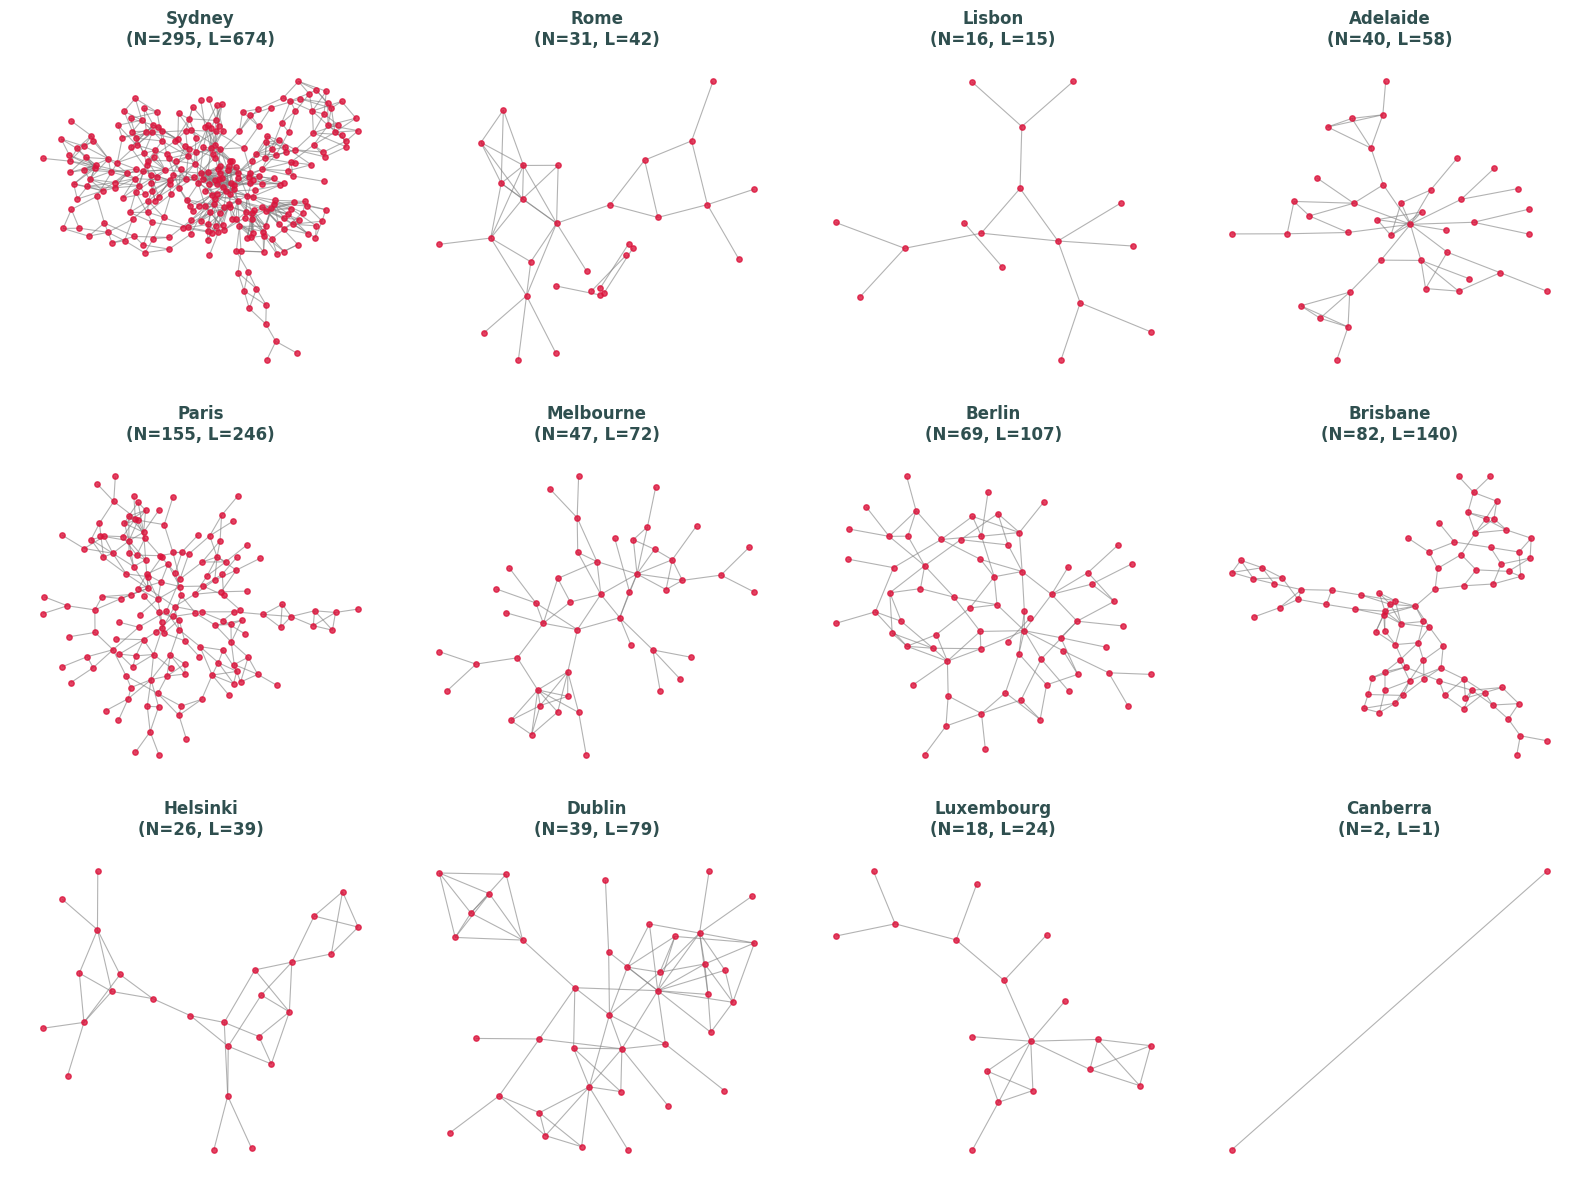

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
import math

# Determinar el tamaño de la cuadrícula basado en la cantidad de ciudades
num_cities = len(city_graphs)
cols = 4  # Usamos 4 columnas por defecto
rows = math.ceil(num_cities / cols)

# Configurar el lienzo principal
fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
axes = axes.flatten()  # Aplanar para iterar fácilmente

# Iterar sobre las ciudades y sus respectivos grafos
for idx, (city, G) in enumerate(city_graphs.items()):
    ax = axes[idx]

    # Calcular la posición de los nodos (layout)
    # Kamada-Kawai suele ser muy bueno para mostrar la topología sin cruzar demasiadas líneas
    try:
        pos = nx.kamada_kawai_layout(G)
    except:
        # Si Kamada-Kawai falla (por ej. si hay islas desconectadas y da error de distancia),
        # usamos el layout de resortes como respaldo
        pos = nx.spring_layout(G, seed=42)

    # Dibujar la red
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color='crimson', node_size=15, alpha=0.8)
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color='gray', width=0.8, alpha=0.6)

    # Ajustes estéticos
    ax.set_title(f"{city.capitalize()}\n(N={G.number_of_nodes()}, L={G.number_of_edges()})",
                 fontsize=12, fontweight='bold', color='darkslategray')
    ax.axis('off')  # Ocultar los ejes y bordes

# Ocultar los gráficos sobrantes si la cuadrícula no está llena
for i in range(num_cities, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

## Ecuaciones matemáticas

### Implementacion ecuaciones

In [ ]:
def compute_theoretical_metrics(G):
    """
    Calcula las 10 métricas teóricas exactas basándose en las Ecuaciones 1-8
    del artículo "Multi-criteria robustness analysis of metro networks".
    """
    N = G.number_of_nodes()
    L = G.number_of_edges()

    # Pre-cálculo de autovalores (Eigenvalues)
    # Autovalores del Laplaciano (ordenados de menor a mayor)
    laplacian_evals = np.sort(nx.laplacian_spectrum(G))
    non_zero_laplacian = [eig for eig in laplacian_evals if eig > 1e-10] # Excluimos el 0

    # Autovalores de la matriz de Adyacencia
    adj_evals = np.real(nx.adjacency_spectrum(G))

    # 1. Indicador de Robustez (r^T) - Eq. 1
    val = L - N + 2
    r_T = np.log(val) / N if val > 0 else 0

    # 2. Conductancia Efectiva del Grafo (C_G) - Eq. 2
    if len(non_zero_laplacian) > 0:
        R_G = N * np.sum(1.0 / np.array(non_zero_laplacian))
        C_G = (N - 1) / R_G
    else:
        C_G = 0

    # 3. Confiabilidad (Rel_G) - Aproximación por puentes (p=0.999)
    # Un puente es un enlace que si falla desconecta la red.
    num_bridges = len(list(nx.bridges(G)))
    Rel_G = 0.999 ** num_bridges

    # 4. Eficiencia Global Promedio (E[1/H]) - Eq. 3
    E_1_H = nx.global_efficiency(G)

    # 5. Coeficiente de Clustering (CC_G) - Eq. 4
    CC_G = nx.average_clustering(G)

    # 6. Conectividad Algebraica Normalizada (\mu_{N-1})
    mu_N_1 = non_zero_laplacian[0] / N if len(non_zero_laplacian) > 0 else 0

    # 7. Grado Promedio Normalizado (E[D]) - Eq. 5
    E_D = (2.0 * L / N) / (N - 1) if N > 1 else 0

    # 8. Conectividad Natural Normalizada (\lambda^*) - Eq. 6
    nat_conn = np.log(np.mean(np.exp(adj_evals)))
    lambda_star = nat_conn / (N - np.log(N)) if N > 0 else 0

    # 9. Diversidad de Grado (1/\kappa) - Eq. 7
    degrees = np.array([d for n, d in G.degree()])
    if np.sum(degrees) > 0:
        kappa = np.sum(degrees**2) / np.sum(degrees)
        inv_kappa = 1.0 / kappa if kappa > 0 else 0
    else:
        inv_kappa = 0

    # 10. Coeficiente de Enmallado (M_G) - Eq. 8
    if N > 2.5: # Evitamos división por cero o negativos en grafos diminutos
        M_G = max(0, (L - N + 1) / (2 * N - 5))
    else:
        M_G = 0

    return {
        'N': N, 'L': L,
        'r^T': r_T, 'C_G': C_G, 'Rel_G': Rel_G,
        'E[1/H]': E_1_H, 'CC_G': CC_G, '\mu_{N-1}': mu_N_1,
        'E[D]': E_D, '\lambda^*': lambda_star,
        '1/\kappa': inv_kappa, 'M_G': M_G
    }

<>:66: SyntaxWarning: invalid escape sequence '\m'
<>:67: SyntaxWarning: invalid escape sequence '\l'
<>:68: SyntaxWarning: invalid escape sequence '\k'
<>:66: SyntaxWarning: invalid escape sequence '\m'
<>:67: SyntaxWarning: invalid escape sequence '\l'
<>:68: SyntaxWarning: invalid escape sequence '\k'
/tmp/ipykernel_10591/1439730786.py:66: SyntaxWarning: invalid escape sequence '\m'
  'E[1/H]': E_1_H, 'CC_G': CC_G, '\mu_{N-1}': mu_N_1,
/tmp/ipykernel_10591/1439730786.py:67: SyntaxWarning: invalid escape sequence '\l'
  'E[D]': E_D, '\lambda^*': lambda_star,
/tmp/ipykernel_10591/1439730786.py:68: SyntaxWarning: invalid escape sequence '\k'
  '1/\kappa': inv_kappa, 'M_G': M_G


### Ejecucion y creación tabla teórica

In [ ]:
print("Calculando las 10 métricas teóricas para todas las ciudades...\n")

# Lista para almacenar los resultados
theoretical_results = []

for city, G in city_graphs.items():
    # Extraemos el componente gigante (matemáticas del espectro fallan en redes desconectadas)
    if nx.is_connected(G):
        G_calc = G
    else:
        largest_cc = max(nx.connected_components(G), key=len)
        G_calc = G.subgraph(largest_cc).copy()

    # Calculamos métricas
    metrics = compute_theoretical_metrics(G_calc)

    # Añadimos el nombre de la ciudad
    metrics_row = {'City': city.capitalize()}
    metrics_row.update(metrics)
    theoretical_results.append(metrics_row)

# Creamos el DataFrame simulando la 'Table 1' del paper
df_theoretical = pd.DataFrame(theoretical_results).set_index('City')

# Mostramos la tabla redondeando a 3 decimales para emular la vista del artículo
display(df_theoretical.round(3))

Calculando las 10 métricas teóricas para todas las ciudades...



,N,L,r^T,C_G,Rel_G,E[1/H],CC_G,\mu_{N-1},E[D],\lambda^*,1/\kappa,M_G
City,,,,,,,,,,,,
Sydney,293,673,0.020,0.006,0.990,0.219,0.187,0.000,0.016,0.011,0.167,0.656
Rome,23,38,0.123,0.042,0.991,0.428,0.297,0.004,0.150,0.114,0.211,0.390
Lisbon,14,14,0.050,0.053,0.989,0.440,0.055,0.015,0.154,0.084,0.359,0.043
Adelaide,40,58,0.075,0.020,0.984,0.358,0.304,0.003,0.074,0.047,0.224,0.253
Paris,113,186,0.038,0.006,0.970,0.217,0.310,0.000,0.029,0.018,0.238,0.335
Melbourne,47,72,0.070,0.018,0.980,0.323,0.251,0.002,0.067,0.043,0.225,0.292
Berlin,67,106,0.055,0.017,0.981,0.296,0.135,0.002,0.048,0.025,0.245,0.310
Brisbane,82,140,0.050,0.008,0.991,0.225,0.095,0.000,0.042,0.021,0.261,0.371
Helsinki,26,39,0.104,0.033,0.993,0.365,0.194,0.003,0.120,0.065,0.281,0.298


## Experimentos numéricos

### Definición del Motor de Ataques y Simulaciones

In [ ]:
def simulate_robustness(G, attack_type="degree", runs=100):
    """
    Replica la metodología del paper para encontrar los umbrales f_90% y f_c,
    y además guarda el historial del tamaño del componente gigante para graficar.
    """
    N_orig = G.number_of_nodes()
    if N_orig <= 1:
        return 0.0, 0.0, [N_orig, 0]

    f90_list = []
    fc_list = []

    # Matriz para guardar el historial de la caída: filas=corridas, columnas=pasos(0 a N_orig)
    history_matrix = np.zeros((runs, N_orig + 1))

    for run_idx in range(runs):
        G_temp = G.copy()
        nodes_removed = 0
        f90 = None
        fc = None

        # Paso 0: la red está intacta
        history_matrix[run_idx, 0] = N_orig

        if attack_type == "random":
            # Barajamos los nodos aleatoriamente antes de empezar
            nodes_to_remove = list(G_temp.nodes())
            random.shuffle(nodes_to_remove)

        for i in range(N_orig):
            # Nota: Eliminamos el 'break' temprano para poder graficar la curva completa hasta 0.

            if attack_type == "degree":
                # Recálculo dinámico: buscar siempre el nodo que actualmente tiene el grado máximo
                degrees = dict(G_temp.degree())
                if not degrees:
                    lcc_size = 0
                else:
                    max_deg = max(degrees.values())
                    candidates = [n for n, d in degrees.items() if d == max_deg]
                    node_to_remove = random.choice(candidates)
            else:
                node_to_remove = nodes_to_remove[i]

            # Destruir el nodo
            if G_temp.has_node(node_to_remove):
                G_temp.remove_node(node_to_remove)

            nodes_removed += 1

            # Calcular el tamaño del Componente Conectado Más Grande (LCC)
            if G_temp.number_of_nodes() == 0:
                lcc_size = 0
            else:
                lcc_size = len(max(nx.connected_components(G_temp), key=len))

            # Guardamos el tamaño actual en el historial
            history_matrix[run_idx, nodes_removed] = lcc_size

            # Verificar Umbral f_90% (primer momento en que el LCC baja del 90%)
            if f90 is None and lcc_size < 0.90 * N_orig:
                f90 = nodes_removed / N_orig

            # Verificar Umbral f_c (primer momento en que la red se desintegra, LCC <= 1)
            if fc is None and lcc_size <= 1:
                fc = nodes_removed / N_orig

        # Si por alguna razón matemática no se alcanzó, se asume que hubo que remover el 100%
        f90_list.append(f90 if f90 is not None else 1.0)
        fc_list.append(fc if fc is not None else 1.0)

    # Promediar el historial de todas las corridas paso a paso
    avg_history = np.mean(history_matrix, axis=0).tolist()

    # Devolvemos también el historial
    return np.mean(f90_list), np.mean(fc_list), avg_history

### Ejecución Masiva y Consolidación Numérica

In [ ]:
print("Iniciando simulaciones de destrucción (1000 iteraciones por red). Esto puede tomar un momento.\n")
numerical_results = []

# Diccionario global para guardar los historiales que usaremos en la Celda 9.5
history_results = {}

for city, G in city_graphs.items():
    # Aseguramos usar el componente gigante al igual que en la Fase 3
    if not nx.is_connected(G):
        largest_cc = max(nx.connected_components(G), key=len)
        G_calc = G.subgraph(largest_cc).copy()
    else:
        G_calc = G.copy()

    # 1. Ataques Dirigidos (Promediamos 10 corridas por si hay empates de grado)
    f90_deg, fc_deg, hist_deg = simulate_robustness(G_calc, attack_type="degree", runs=10)

    # 2. Fallos Aleatorios (El paper exige 1000 corridas para estabilizar la estadística)
    f90_rand, fc_rand, hist_rand = simulate_robustness(G_calc, attack_type="random", runs=1000)

    numerical_results.append({
        'City': city.capitalize(),
        'f90%_degree': f90_deg,
        'f90%_random': f90_rand,
        'fc_degree': fc_deg,
        'fc_random': fc_rand
    })

    # Guardamos el historial para graficar luego
    history_results[city.capitalize()] = {
        'degree': hist_deg,
        'random': hist_rand,
        'N_orig': G_calc.number_of_nodes()
    }

# Creamos el DataFrame correspondiente a las métricas numéricas de la Tabla 1
df_numerical = pd.DataFrame(numerical_results).set_index('City')

# Unimos la tabla teórica y la numérica en un DataFrame Maestro (Consolidación)
df_master = df_theoretical.join(df_numerical)

print("Simulaciones completadas. Aquí están los 4 umbrales críticos calculados:")
display(df_master[['f90%_degree', 'f90%_random', 'fc_degree', 'fc_random']].round(2))

Iniciando simulaciones de destrucción (1000 iteraciones por red). Esto puede tomar un momento.

Simulaciones completadas. Aquí están los 4 umbrales críticos calculados:


,f90%_degree,f90%_random,fc_degree,fc_random
City,,,,
Sydney,0.05,0.10,0.58,0.97
Rome,0.04,0.10,0.48,0.86
Lisbon,0.07,0.11,0.36,0.78
Adelaide,0.02,0.08,0.45,0.89
Paris,0.05,0.07,0.56,0.94
Melbourne,0.02,0.07,0.45,0.89
Berlin,0.05,0.08,0.49,0.92
Brisbane,0.02,0.08,0.55,0.93
Helsinki,0.04,0.09,0.46,0.87


En casi todas las ciudades los valores de f_c_degree (destruir la red atacando las estaciones más conectadas) son mucho más bajos que los de f_c_random (destruir al azar).

Esto indica, por ejemplo, que con destruir  en Sydney el 58% de los nodos principales la red se desintegra, pero si los fallos son aleatorios la red va a sobrevivir hasta que se pierda el 97% de las estaciones. Esto nos confirma el principio matemático del paper, que dice que las redes de transportes son muy resistentes a accidentes aleatorios, pero muy vulnerables a ataques dirigidos a sus hubs.

### Gráficas de las Curvas de Robustez

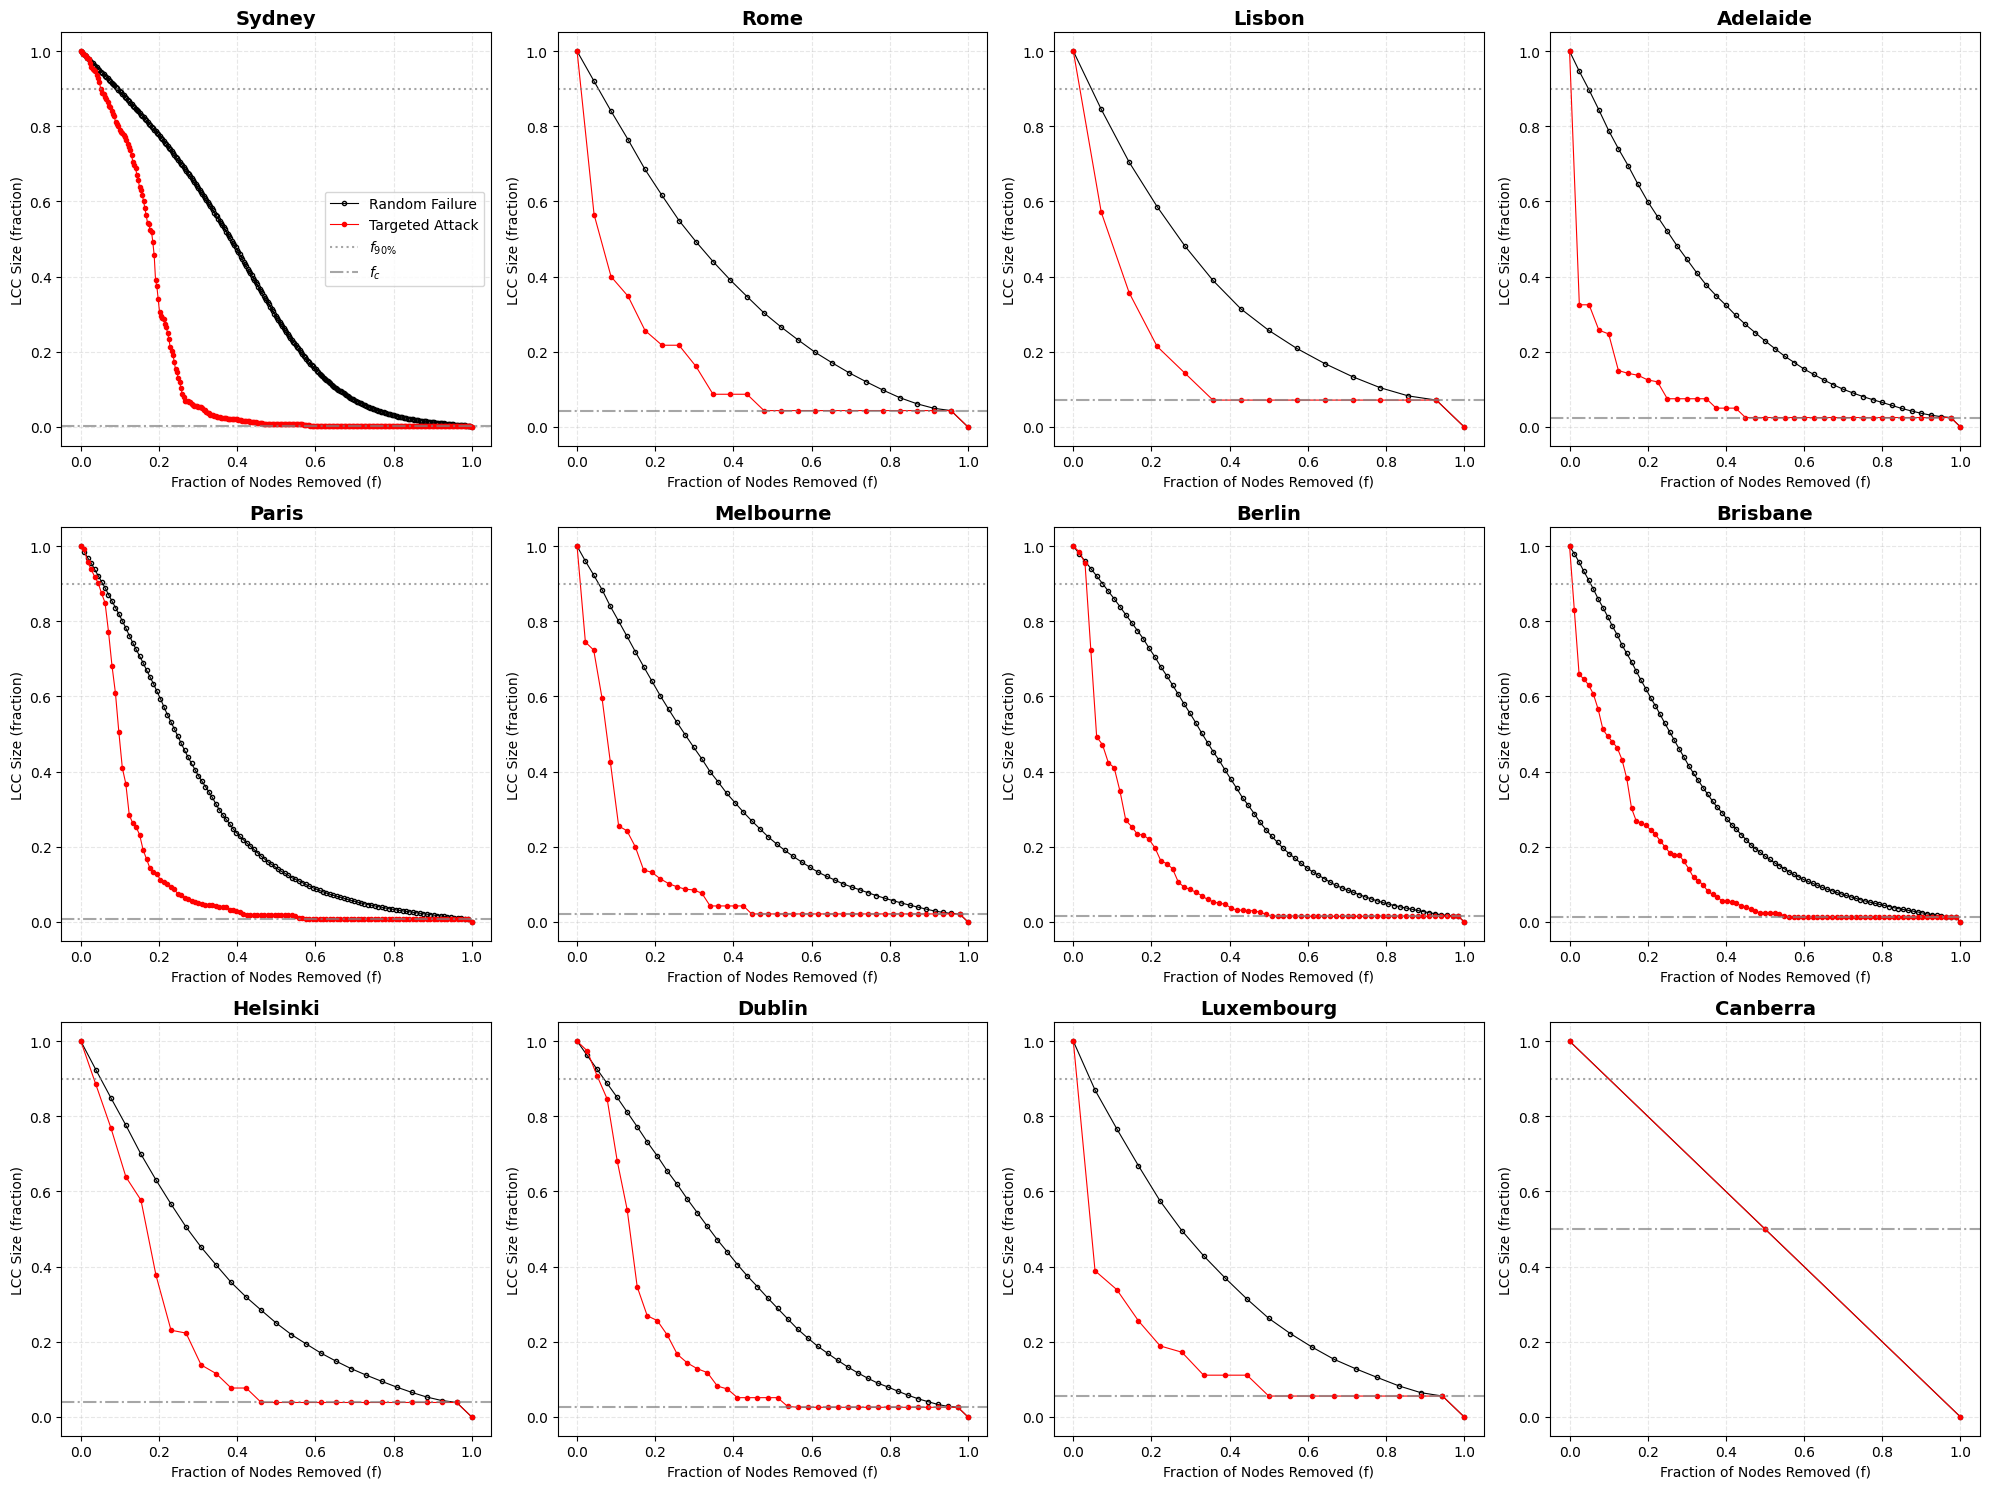

In [ ]:
# Seleccionamos todas las ciudades disponibles
all_cities = list(history_results.keys())
num_cities = len(all_cities)

# Calculamos dimensiones de la cuadrícula (3 filas x 4 columnas para 12 ciudades)
cols = 4
rows = (num_cities + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(20, 5 * rows))
axes = axes.flatten()

for i, city in enumerate(all_cities):
    ax = axes[i]
    hist_deg = history_results[city]['degree']
    hist_rand = history_results[city]['random']
    N = history_results[city]['N_orig']

    # Normalizamos el eje X (fracción de nodos removidos) para facilitar la comparación visual
    x_vals = [n / N for n in range(N + 1)]

    # Normalizamos el eje Y (fracción del componente gigante)
    y_rand = [size / N for size in hist_rand]
    y_deg = [size / N for size in hist_deg]

    # Graficar curvas
    ax.plot(x_vals, y_rand, marker='o', markerfacecolor='none', markersize=3,
            color='black', linestyle='-', linewidth=0.8, label='Random Failure')
    ax.plot(x_vals, y_deg, marker='o', color='red', markersize=3,
            linestyle='-', linewidth=0.8, label='Targeted Attack')

    # Líneas de umbral teórico
    ax.axhline(y=0.9, color='gray', linestyle=':', alpha=0.7, label=r'$f_{90\%}$')
    ax.axhline(y=1/N, color='gray', linestyle='-.', alpha=0.7, label=r'$f_c$')

    ax.set_title(f'{city}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Fraction of Nodes Removed (f)', fontsize=10)
    ax.set_ylabel('LCC Size (fraction)', fontsize=10)
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, linestyle='--', alpha=0.3)

    if i == 0:
        ax.legend()

# Ocultar subplots vacíos si los hay
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

## Consolidación y visualización

### Matriz consolidación

<>:8: SyntaxWarning: invalid escape sequence '\m'
<>:9: SyntaxWarning: invalid escape sequence '\l'
<>:10: SyntaxWarning: invalid escape sequence '\k'
<>:8: SyntaxWarning: invalid escape sequence '\m'
<>:9: SyntaxWarning: invalid escape sequence '\l'
<>:10: SyntaxWarning: invalid escape sequence '\k'
/tmp/ipykernel_10591/1766713189.py:8: SyntaxWarning: invalid escape sequence '\m'
  '\mu_{N-1}': r'$\mu_{N-1}$',
/tmp/ipykernel_10591/1766713189.py:9: SyntaxWarning: invalid escape sequence '\l'
  '\lambda^*': r'$\lambda^*$',
/tmp/ipykernel_10591/1766713189.py:10: SyntaxWarning: invalid escape sequence '\k'
  '1/\kappa': r'$1/\kappa$'


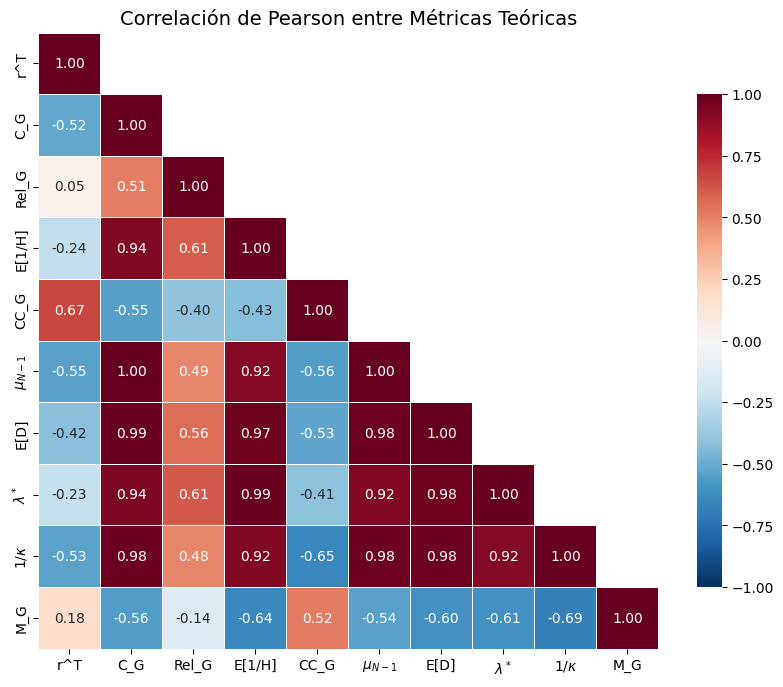


Correlación entre Métricas Teóricas y Umbrales Críticos:


,f90%_degree,f90%_random,fc_degree,fc_random
r^T,-0.54,-0.52,-0.22,0.32
C_G,0.99,1.00,-0.00,-0.93
Rel_G,0.49,0.55,-0.08,-0.56
E[1/H],0.93,0.94,-0.23,-0.98
CC_G,-0.55,-0.59,0.24,0.55
$\mu_{N-1}$,0.99,1.00,0.02,-0.92
E[D],0.98,0.99,-0.08,-0.97
$\lambda^*$,0.93,0.94,-0.16,-0.97
$1/\kappa$,0.97,0.98,-0.12,-0.96
M_G,-0.54,-0.55,0.67,0.75


In [ ]:
# Definimos las columnas a comparar
cols_teoricas = ['r^T', 'C_G', 'Rel_G', 'E[1/H]', 'CC_G', r'\mu_{N-1}', 'E[D]', r'\lambda^*', r'1/\kappa', 'M_G']
cols_numericas = ['f90%_degree', 'f90%_random', 'fc_degree', 'fc_random']

# Renombramos las columnas del df_master temporalmente para que los gráficos luzcan bien
df_plot = df_master.copy()
df_plot.rename(columns={
    '\mu_{N-1}': r'$\mu_{N-1}$',
    '\lambda^*': r'$\lambda^*$',
    '1/\kappa': r'$1/\kappa$'
}, inplace=True)

cols_teoricas_plot = ['r^T', 'C_G', 'Rel_G', 'E[1/H]', 'CC_G', r'$\mu_{N-1}$', 'E[D]', r'$\lambda^*$', r'$1/\kappa$', 'M_G']

# 1. Matriz de Correlación de Pearson entre las métricas teóricas
corr_teoricas = df_plot[cols_teoricas_plot].corr()

# Creamos una máscara para ocultar el triángulo superior (dejando la diagonal)
mask = np.triu(np.ones_like(corr_teoricas, dtype=bool), k=1)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_teoricas, mask=mask, annot=True, cmap='RdBu_r', vmin=-1, vmax=1, fmt=".2f",
            linewidths=.5, cbar_kws={"shrink": .8})
plt.title('Correlación de Pearson entre Métricas Teóricas', fontsize=14)
plt.show()

# 2. Correlación con los umbrales numéricos
print("\nCorrelación entre Métricas Teóricas y Umbrales Críticos:")
corr_matrix = df_plot[cols_teoricas_plot + cols_numericas].corr()
display(corr_matrix.loc[cols_teoricas_plot, cols_numericas].round(2))

### Diagramas de Radar y Ranking Final

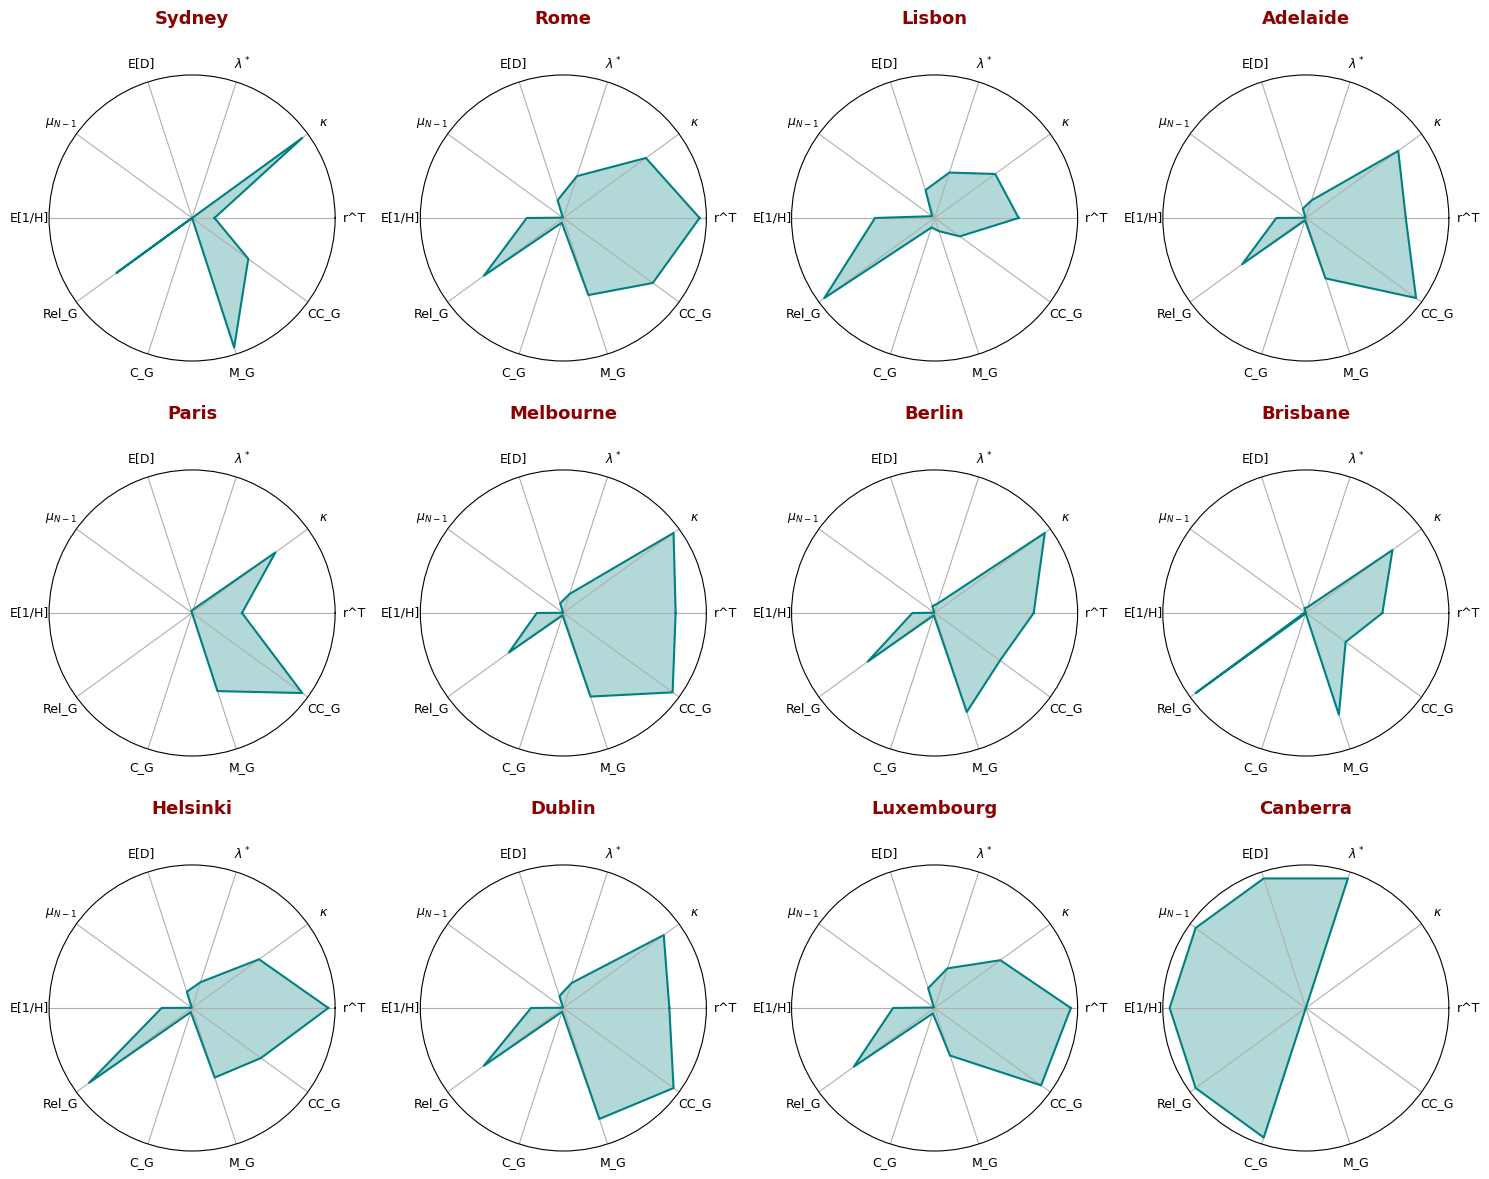


RANKING FINAL DE ROBUSTEZ GLOBAL


,Área_Robustez_Global
City,
Canberra,1.469
Dublin,0.810
Rome,0.756
Luxembourg,0.625
Adelaide,0.420
Helsinki,0.414
Melbourne,0.358
Paris,0.267
Sydney,0.223


In [ ]:
# Calculamos \kappa invirtiendo 1/\kappa (evitando división por cero)
df_plot[r'$\kappa$'] = np.where(df_plot[r'$1/\kappa$'] > 0, 1.0 / df_plot[r'$1/\kappa$'], 0)

# Reordenamos las variables
cols_radar = ['r^T', 'CC_G', 'M_G', 'C_G', 'Rel_G', 'E[1/H]', r'$\mu_{N-1}$', 'E[D]', r'$\lambda^*$', r'$\kappa$']

# 1. Estandarización Min-Max (Llevar todos los valores a la escala 0-1) con el nuevo orden
df_norm = (df_plot[cols_radar] - df_plot[cols_radar].min()) / (df_plot[cols_radar].max() - df_plot[cols_radar].min())
df_norm = df_norm.fillna(0) # Protegemos contra divisiones por cero en ciudades como Canberra

# 2. Función matemática para calcular el área del polígono (Robustez Global)
def poly_area(radii):
    n = len(radii)
    area = 0
    for i in range(n):
        area += 0.5 * radii[i] * radii[(i+1)%n] * np.sin(2 * np.pi / n)
    return area

# Calculamos el área para cada ciudad y lo guardamos
areas = {}
for city in df_norm.index:
    areas[city] = poly_area(df_norm.loc[city].values)

df_master['Área_Robustez_Global'] = pd.Series(areas)

# 3. Dibujar los Diagramas de Radar
num_vars = len(cols_radar)
angles = [n / float(num_vars) * 2 * pi for n in range(num_vars)]
angles += angles[:1] # Repetir el primer ángulo para cerrar el círculo

# Configuramos la cuadrícula de gráficos (3 filas x 4 columnas = 12 ciudades)
fig, axs = plt.subplots(3, 4, figsize=(15, 12), subplot_kw=dict(polar=True))
axs = axs.flatten()

for idx, city in enumerate(df_norm.index):
    values = df_norm.loc[city].values.flatten().tolist()
    values += values[:1] # Repetir el primer valor para cerrar el polígono

    ax = axs[idx]

    # Invertimos la dirección de Matplotlib para que gire en sentido horario
    ax.set_theta_direction(-1)

    ax.plot(angles, values, linewidth=1.5, linestyle='solid', color='teal')
    ax.fill(angles, values, 'teal', alpha=0.3)

    # Etiquetas y diseño
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(cols_radar, fontsize=9)
    ax.set_title(city, size=13, color='darkred', y=1.15, fontweight='bold')
    ax.set_yticks([]) # Ocultar los anillos numéricos para un diseño más limpio

plt.tight_layout()
plt.show()

# 4. Mostrar el Ranking Final
print("\n" + "="*40)
print("RANKING FINAL DE ROBUSTEZ GLOBAL")
print("="*40)
ranking = df_master[['Área_Robustez_Global']].sort_values(by='Área_Robustez_Global', ascending=False)
display(ranking.round(3))

## Explicación métrica $\bar{\lambda}$

**Conectividad Natural ($\bar{\lambda}$):** Es una métrica avanzada de robustez estructural que cuantifica la redundancia de rutas en la red. A diferencia de otras métricas que solo consideran los caminos más cortos, la conectividad natural toma en cuenta los "paseos cerrados" (closed walks) de todas las longitudes posibles, otorgando mayor peso a los trayectos más cortos.

**Definición Matemática:**
Se calcula a partir del espectro de la matriz de adyacencia de la red, utilizando la siguiente ecuación:
$$\bar{\lambda} = \ln\left[\frac{1}{N}\sum_{i=1}^{N}e^{\lambda_i}\right]$$
Donde:
* $N$ es el número total de nodos (estaciones terminales y de transferencia).
* $\lambda_i$ representa los autovalores (eigenvalues) de la matriz de adyacencia del grafo.

**Interpretación en el Transporte:**
* Redundancia: Un valor más alto indica mayor cantidad de rutas alternativas. Si una estación principal falla, los pasajeros tienen múltiples formas de rodear el problema para llegar a su destino.
* Sensibilidad: Es una métrica monótona y altamente sensible a los cambios topológicos. Incluso la caída de un solo tramo ferroviario (enlace) se refleja inmediatamente en una disminución de este valor, haciéndola ideal para medir ataques progresivos.

**Normalización ($\lambda^*$):**
El valor bruto de $\bar{\lambda}$ crece en redes más grandes, dificultando la comparación entre ciudades de distinto tamaño (ej. Roma vs. París). Por ello, el experimento utiliza la conectividad natural normalizada ($\lambda^*$). Esto se logra dividiendo el valor obtenido por el máximo teórico posible, el cual corresponde al de un grafo completo (donde todas las estaciones conectan directamente con todas las demás):
$$\lambda^* = \frac{\bar{\lambda}}{N - \ln N}$$
De esta manera, la métrica se escala, permitiendo evaluar qué tan cerca está una red del diseño más robusto teóricamente posible según su tamaño.